### Tasks

* 1. Write a Python function compute_gradient(f, x) that takes a simple function f (like f(x) = x**2) and a value x, and returns the numerical gradient at x using the central difference method.<br><br><em><strong>Hint:</strong> Use (f(x+h) - f(x-h)) / (2*h) with a small h (e.g., 1e-5).</em>

$$\frac{\partial f}{\partial x} \approx \frac{f(x + h) - f(x - h)}{2h}$$

In [20]:
def compute_gradient(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

f = lambda x: x**2

point = 3.0
gradient = compute_gradient(f, point)

print(f"Numerical gradient of f(x) = x^2 at x={point}: {gradient:.5f}")

Numerical gradient of f(x) = x^2 at x=3.0: 6.00000


* 2. Given the function f(x, y) = x**2 + y**2, calculate the partial derivatives with respect to x and y at the point (x=3, y=4) using Python.

$f(x, y) = x^2 + y^2$ at $(3, 4)$
$$\frac{\partial f}{\partial x} = 2x \implies 2(3) = 6$$
$$\frac{\partial f}{\partial y} = 2y \implies 2(4) = 8$$


In [21]:
def f(x, y):
    return x**2 + y**2

def partial_x(f, x, y, h=1e-5):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-5):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

In [22]:
x_val, y_val = 3.0, 4.0
df_dx = partial_x(f, x_val, y_val)
df_dy = partial_y(f, x_val, y_val)

In [23]:
print(f"Partial derivative w.r.t x at (3,4): {df_dx:.4f}")
print(f"Partial derivative w.r.t y at (3,4): {df_dy:.4f}")

Partial derivative w.r.t x at (3,4): 6.0000
Partial derivative w.r.t y at (3,4): 8.0000


* 3. Simulate one step of gradient descent for a function f(w) = (w-5)**2 starting from w=0, with a learning rate of 0.1. Print the updated value of w after the step.

#### One Step of Gradient Descent
#### For $f(w) = (w - 5)^2$, the analytical gradient is $\frac{df}{dw} = 2(w - 5)$.
The update rule is:
$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{df}{dw}$$

At $w = 0$ and $\eta = 0.1$:
$$\frac{df}{dw}\Big\vert{}_{w=0} = 2(0 - 5) = -10$$
$$w_{\text{new}} = 0 - 0.1(-10) = 1.0$$

In [24]:
def grad_f(w):
    return 2 * (w - 5)

In [25]:
w = 0.0
learning_rate = 0.1

w = w - learning_rate * grad_f(w)

In [26]:
print(f"Updated value of w after one step: {w:.2f}")

Updated value of w after one step: 1.00


* 4. Create a Python script that demonstrates how different learning rates (0.01, 0.1, 0.5) affect the convergence of gradient descent for f(x) = (x-3)**2. Plot the value of x over 20 iterations for each learning rate using matplotlib.<br><br><em><strong>Hint:</strong> Use a loop to update x for each learning rate and plot all three on the same graph.</em>

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
def grad_f(x):
    return 2 * (x - 3)

learning_rates = [0.01, 0.1, 0.5]
iterations = 20

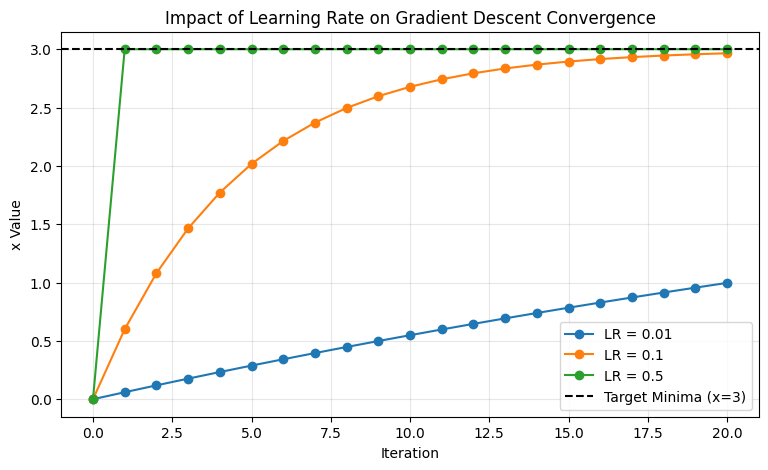

In [29]:
plt.figure(figsize=(9, 5))

for lr in learning_rates:
    x = 0.0
    history = [x]
    
    for _ in range(iterations):
        x = x - lr * grad_f(x)
        history.append(x)
        
    plt.plot(range(iterations + 1), history, marker='o', label=f'LR = {lr}')

plt.axhline(3.0, color='black', linestyle='--', label='Target Minima (x=3)')
plt.title('Impact of Learning Rate on Gradient Descent Convergence')
plt.xlabel('Iteration')
plt.ylabel('x Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

* 5. Write a short Python function that generates and plots a graph of f(x) = x**4 - 3x**3 + 2 for x in range(-2, 4), and visually identify one local minimum and the global minimum on the plot.

#### Plotting Polynomial Function & Visualizing Minima
#### For $f(x) = x^4 - 3x^3 + 2$:
#### Derivative: $f'(x) = 4x^3 - 9x^2 = x^2(4x - 9)$
#### Critical Points: $x = 0$ (inflection point) and $x = 2.25$ (Global Minimum)
#### Boundary: $x = -2$ acts as a Local Minimum on the bounded interval $[-2, 4]$.

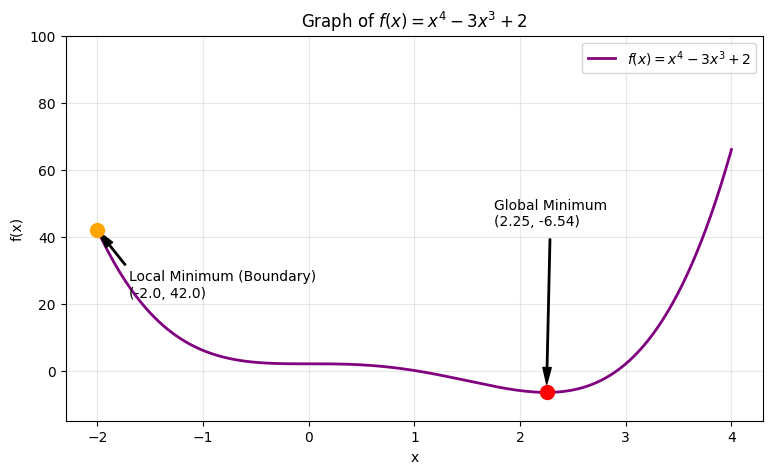

In [ ]:
def plot_function_and_minima():
    x = np.linspace(-2, 4, 400)
    y = x**4 - 3*x**3 + 2
    
    x_global_min = 2.25
    y_global_min = x_global_min**4 - 3*x_global_min**3 + 2
    
    x_local_min = -2.0
    y_local_min = x_local_min**4 - 3*x_local_min**3 + 2

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, label=r'$f(x) = x^4 - 3x^3 + 2$', color='purple', linewidth=2)
    
    plt.scatter([x_global_min], [y_global_min], color='red', s=100, zorder=5)
    plt.annotate(f'Global Minimum\n({x_global_min:.2f}, {y_global_min:.2f})',
                 xy=(x_global_min, y_global_min),
                 xytext=(x_global_min - 0.5, y_global_min + 50),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
    
    plt.scatter([x_local_min], [y_local_min], color='orange', s=100, zorder=5)
    plt.annotate(f'Local Minimum (Boundary)\n({x_local_min}, {y_local_min})',
                 xy=(x_local_min, y_local_min),
                 xytext=(x_local_min + 0.3, y_local_min - 20),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

    plt.title(r'Graph of $f(x) = x^4 - 3x^3 + 2$')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.ylim(-15, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_function_and_minima()